In [3]:
from pathlib import Path
print(Path.cwd())

c:\Users\SJ\project\SKN_34_2st\SKN34-2nd-2Team\analytics


In [14]:
#한글 폰트 설정 (Mac은 AppleGothic)
plt.rcParams["font.family"] = "Malgun Gothic"

#마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

In [4]:
from pathlib import Path
print(list(Path("../data").iterdir()))

[WindowsPath('../data/processed'), WindowsPath('../data/raw')]


In [6]:
PROCESSED_DIR = Path("../data/processed")
df = pd.read_csv(PROCESSED_DIR / "features_transactions.csv")
print(df.columns.tolist())
df.head()

['msno', 'txn_count', 'payment_method_nunique', 'plan_days_nunique', 'auto_renew_rate', 'cancel_count', 'cancel_rate', 'total_amount_paid', 'avg_discount', 'last_payment_plan_days', 'last_plan_list_price', 'last_actual_amount_paid', 'last_is_auto_renew', 'days_since_last_txn', 'days_to_expire']


,msno,txn_count,payment_method_nunique,plan_days_nunique,auto_renew_rate,cancel_count,cancel_rate,total_amount_paid,avg_discount,last_payment_plan_days,last_plan_list_price,last_actual_amount_paid,last_is_auto_renew,days_since_last_txn,days_to_expire
0,+++FOrTS7ab3tIgIh8eWwX4FqRv8w/FoiOuyXsFvphY=,1,1,1,0.0,0,0.0,0,0.000000,7,0,0,0,172,-167.0
1,+++IZseRRiQS9aaSkH6cMYU6bGDcxUieAi/tH67sC5s=,1,1,1,0.0,0,0.0,1788,0.000000,410,1788,1788,0,465,-55.0
2,+++hVY1rZox/33YtvDgmKA2Frg/2qhkz12B9ylCvh8o=,4,1,1,1.0,0,0.0,396,0.000000,30,99,99,1,13,15.0
3,+++l/EXNMLTijfLBa8p2TUVVVp2aFGSuUI/h7mLmthw=,19,1,3,1.0,0,0.0,2831,-7.842105,30,149,149,1,28,19.0
4,+++snpr7pmobhLKUgSHTv/mpkqgBT0tQJ0zQj6qKrqc=,26,1,2,1.0,0,0.0,3874,-5.730769,30,149,149,1,2,26.0


In [7]:
members = pd.read_csv(PROCESSED_DIR / "features_members.csv")
print(members.columns.tolist())

['msno', 'city', 'registered_via', 'bd_clean', 'bd_is_missing', 'gender', 'tenure_days']


In [8]:
members = pd.read_csv(PROCESSED_DIR / "features_members.csv")
labels = pd.read_csv(PROCESSED_DIR / "labels_pooled.csv")

print(labels.columns.tolist())  # is_churn 컬럼명 정확히 확인


['msno', 'snapshot', 'is_churn']


In [9]:
print(labels["snapshot"].unique())
print(labels.groupby("msno").size().value_counts())  # 유저당 몇 번 나오는지

<ArrowStringArray>
['2017-02']
Length: 1, dtype: str
1    992931
Name: count, dtype: int64


In [10]:
survival_df = members[["msno", "tenure_days"]].merge(
    labels[["msno", "is_churn"]], on="msno", how="inner"
)

survival_df = survival_df.rename(columns={
    "tenure_days": "duration",
    "is_churn": "event"
})

print(survival_df.shape)
survival_df.head()

(877161, 3)


,msno,duration,event
0,+tJonkh+O1CA796Fm5X60UMOtB6POHAwPjbTRVl/EuU=,1994,0
1,yLkV2gbZ4GLFwqTOXLVHz0VGrMYcgBGgKZ3kj9RiYu8=,1992,0
2,WH5Jq4mgtfUFXh2yz+HrcTXKS4Oess4k4W3qKolAeb0=,1992,1
3,I0yFvqMoNkM8ZNHb617e1RBzIS/YRKemHO7Wj13EtA0=,1990,0
4,OoDwiKZM+ZGr9P3fRivavgOtglTEaNfWJO4KaJcTTts=,1990,0


In [11]:
import lifelines
print(lifelines.__version__)

0.30.3


<Axes: xlabel='timeline'>

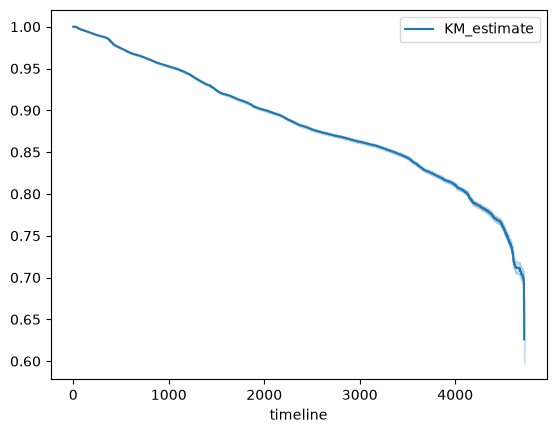

In [12]:
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
kmf.fit(durations=survival_df["duration"], event_observed=survival_df["event"])
kmf.plot_survival_function()

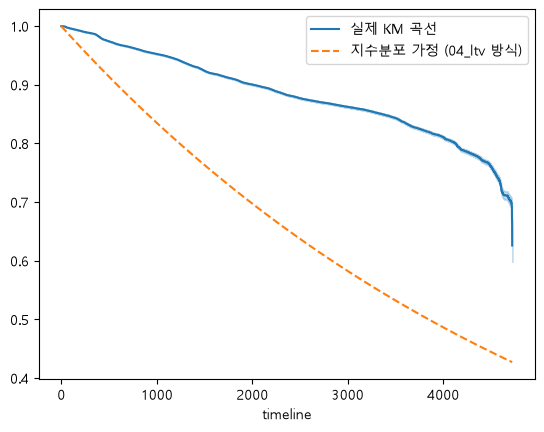

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# 전체 평균 이탈률로 지수분포 가정 생존곡선 그리기
avg_churn_rate = survival_df["event"].mean()
t = np.linspace(0, survival_df["duration"].max(), 100)
exponential_survival = np.exp(-avg_churn_rate/365 * t)  # 대략적인 근사

ax = kmf.plot_survival_function(label="실제 KM 곡선")
plt.plot(t, exponential_survival, label="지수분포 가정 (04_ltv 방식)", linestyle="--")
plt.legend()

In [18]:
transactions = pd.read_csv(PROCESSED_DIR / "features_transactions.csv")

cox_df = survival_df.merge(members[["msno", "city", "gender", "bd_clean"]], on="msno")
cox_df = cox_df.merge(
    transactions[["msno", "auto_renew_rate", "cancel_rate", "avg_discount"]],
    on="msno"
)
cox_df = cox_df.drop(columns=["msno"])
cox_df = pd.get_dummies(cox_df, columns=["gender", "city"], drop_first=True)

print(cox_df.shape)
cox_df.head()

(877161, 28)


,duration,event,bd_clean,auto_renew_rate,cancel_rate,avg_discount,gender_male,gender_unknown,city_3,city_4,...,city_13,city_14,city_15,city_16,city_17,city_18,city_19,city_20,city_21,city_22
0,1994,0,NaN,1.0,0.034483,-5.137931,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1992,0,30.0,1.0,0.000000,-7.842105,True,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2,1992,1,34.0,0.0,0.000000,0.000000,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1990,0,63.0,1.0,0.000000,-5.730769,True,False,False,False,...,True,False,False,False,False,False,False,False,False,False
4,1990,0,NaN,1.0,0.000000,-5.730769,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [19]:
print(cox_df.isnull().sum())

duration                0
event                   0
bd_clean           488021
auto_renew_rate         0
cancel_rate             0
avg_discount            0
gender_male             0
gender_unknown          0
city_3                  0
city_4                  0
city_5                  0
city_6                  0
city_7                  0
city_8                  0
city_9                  0
city_10                 0
city_11                 0
city_12                 0
city_13                 0
city_14                 0
city_15                 0
city_16                 0
city_17                 0
city_18                 0
city_19                 0
city_20                 0
city_21                 0
city_22                 0
dtype: int64


In [21]:
print(cox_df["bd_clean"].isnull().sum())

0


In [22]:
print(cox_df.nunique())

duration           4718
event                 2
bd_clean            100
auto_renew_rate     340
cancel_rate         170
avg_discount       2140
gender_male           2
gender_unknown        2
city_3                2
city_4                2
city_5                2
city_6                2
city_7                2
city_8                2
city_9                2
city_10               2
city_11               2
city_12               2
city_13               2
city_14               2
city_15               2
city_16               2
city_17               2
city_18               2
city_19               2
city_20               2
city_21               2
city_22               2
dtype: int64


In [23]:
cph = CoxPHFitter(penalizer=0.1)
cph.fit(cox_df, duration_col="duration", event_col="event")
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 877161 total observations, 819506 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 877161
number of events observed = 57655
   partial log-likelihood = -706438.83
         time fit was run = 2026-08-02 06:42:51 UTC

---
                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                        
bd_clean        -0.02      0.98      0.00           -0.02           -0.02                0.98                0.98
auto_renew_rate -1.55      0.21      0.01           -1.57           -1.54                0.21                0.21
cancel_rate      5.72    303.62      0.04            5.63            5.80              278.67              330.81
avg_discount     0.01      1.01      0.00            0.01            0.01                1.01                1.01
gender_male     -0.04      0.96      0.01           -0.05           -0.03                0.95                0.97
gender_unknown   0.14      1.15      0.01            0.13            0.15                1.13                1.16
city_3          -0.11      0.90      0.03           -0.17           -0.04                0.84                0.96
city_4          -0.05      0.95      0.01           -0.07           -0.03                0.93                0.97
city_5          -0.06      0.94      0.01           -0.08           -0.04                0.92                0.96
city_6          -0.07      0.93      0.01           -0.10           -0.04                0.91                0.96
city_7          -0.19      0.82      0.04           -0.28           -0.11                0.75                0.90
city_8          -0.03      0.97      0.03           -0.08            0.02                0.93                1.02
city_9          -0.08      0.92      0.02           -0.13           -0.04                0.88                0.96
city_10         -0.05      0.95      0.03           -0.11            0.00                0.90                1.00
city_11         -0.09      0.91      0.02           -0.14           -0.05                0.87                0.95
city_12         -0.04      0.96      0.02           -0.08           -0.00                0.92                1.00
city_13         -0.15      0.86      0.01           -0.17           -0.14                0.84                0.87
city_14         -0.09      0.91      0.02           -0.12           -0.06                0.88                0.94
city_15         -0.09      0.91      0.01           -0.12           -0.07                0.89                0.93
city_16         -0.10      0.91      0.07           -0.24            0.05                0.79                1.05
city_17         -0.11      0.90      0.03           -0.17           -0.05                0.85                0.96
city_18         -0.09      0.91      0.03           -0.14           -0.04                0.87                0.96
city_19         -0.21      0.81      0.19           -0.59            0.17                0.56                1.18
city_20         -0.08      0.92      0.09           -0.25            0.09                0.78                1.10
city_21         -0.02      0.98      0.03           -0.08            0.04                0.92                1.04
city_22         -0.08      0.92      0.01           -0.11           -0.06                0.90                0.94

                 cmp to       z      p  -log2(p)
covariate                                       
bd_clean           0.00  -36.86 <0.005    985.80
auto_renew_rate    0.00 -216.55 <0.005       inf
cancel_rate        0.00  130.63 <0.005       inf
avg_discount       0.00   42.57 <0.005       inf
gender_male        0.00   -6.21 <0.005     30.86
gender_unknown     0.00  

### cancel_rate 포함 시 결과 (데이터 누수 의심되어 비교용으로 남김)

In [24]:
cox_df_v2 = cox_df.drop(columns=["cancel_rate"])
cph_v2 = CoxPHFitter(penalizer=0.1)
cph_v2.fit(cox_df_v2, duration_col="duration", event_col="event")
cph_v2.print_summary()

<lifelines.CoxPHFitter: fitted with 877161 total observations, 819506 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 877161
number of events observed = 57655
   partial log-likelihood = -711920.21
         time fit was run = 2026-08-02 06:44:49 UTC

---
                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                        
bd_clean        -0.02      0.98      0.00           -0.02           -0.02                0.98                0.98
auto_renew_rate -1.48      0.23      0.01           -1.49           -1.46                0.23                0.23
avg_discount     0.01      1.01      0.00            0.01            0.01                1.01                1.01
gender_male     -0.04      0.96      0.01           -0.05           -0.03                0.95                0.97
gender_unknown   0.13      1.14      0.01            0.12            0.15                1.13                1.16
city_3          -0.11      0.90      0.03           -0.17           -0.04                0.84                0.96
city_4          -0.05      0.95      0.01           -0.07           -0.03                0.93                0.97
city_5          -0.06      0.95      0.01           -0.07           -0.04                0.93                0.96
city_6          -0.07      0.93      0.01           -0.10           -0.04                0.91                0.96
city_7          -0.17      0.84      0.04           -0.26           -0.09                0.77                0.92
city_8          -0.03      0.97      0.03           -0.08            0.02                0.92                1.02
city_9          -0.08      0.92      0.02           -0.13           -0.04                0.88                0.96
city_10         -0.05      0.95      0.03           -0.10            0.01                0.90                1.01
city_11         -0.09      0.91      0.02           -0.14           -0.05                0.87                0.95
city_12         -0.04      0.96      0.02           -0.08            0.00                0.92                1.00
city_13         -0.15      0.86      0.01           -0.16           -0.13                0.85                0.88
city_14         -0.09      0.91      0.02           -0.12           -0.06                0.88                0.94
city_15         -0.09      0.91      0.01           -0.11           -0.07                0.89                0.93
city_16         -0.10      0.91      0.07           -0.24            0.04                0.78                1.05
city_17         -0.10      0.90      0.03           -0.16           -0.04                0.85                0.96
city_18         -0.09      0.91      0.03           -0.14           -0.04                0.87                0.96
city_19         -0.22      0.80      0.19           -0.60            0.15                0.55                1.16
city_20         -0.10      0.91      0.09           -0.27            0.08                0.77                1.08
city_21         -0.03      0.97      0.03           -0.09            0.03                0.92                1.03
city_22         -0.08      0.92      0.01           -0.10           -0.06                0.90                0.95

                 cmp to       z      p  -log2(p)
covariate                                       
bd_clean           0.00  -37.18 <0.005   1002.53
auto_renew_rate    0.00 -209.40 <0.005       inf
avg_discount       0.00   51.99 <0.005       inf
gender_male        0.00   -6.19 <0.005     30.63
gender_unknown     0.00   23.35 <0.005    398.22
city_3             0.00   -3.31 <0.005     10.05
city_4             0.00   -4.31 <0.005     15.91
city_5             0.00   -6.04 <0.005   

In [26]:
print(survival_df["duration"].max())

4722


In [27]:
from lifelines.utils import restricted_mean_survival_time

rmst = restricted_mean_survival_time(kmf, t=4722)
print(f"관측 최대 기간(4722일) 기준 기대 잔존 기간(RMST): {rmst:.1f}일")

관측 최대 기간(4722일) 기준 기대 잔존 기간(RMST): 4175.6일


In [28]:
avg_churn_rate = survival_df["event"].mean()
old_expected_lifetime_days = 1 / avg_churn_rate  # 단위 확인 필요 (일 단위 이탈확률인지, 스냅샷 기준 이탈확률인지)

print(f"기존 방식(단순 지수분포 가정): {old_expected_lifetime_days:.0f}일")
print(f"생존분석 기반(RMST): {rmst:.0f}일")
print(f"차이: {rmst - old_expected_lifetime_days:.0f}일")

기존 방식(단순 지수분포 가정): 15일
생존분석 기반(RMST): 4176일
차이: 4160일


In [29]:
low_risk = survival_df.merge(transactions[["msno", "auto_renew_rate"]], on="msno")
low_risk = low_risk[low_risk["auto_renew_rate"] >= 0.9]

kmf_low_risk = KaplanMeierFitter()
kmf_low_risk.fit(durations=low_risk["duration"], event_observed=low_risk["event"])

rmst_low_risk = restricted_mean_survival_time(kmf_low_risk, t=4722)
print(f"저위험군 RMST: {rmst_low_risk:.1f}일 (≈{rmst_low_risk/30:.0f}개월, 기존 상한 60개월)")

저위험군 RMST: 4466.8일 (≈149개월, 기존 상한 60개월)
